# Random Forest Importance Expanded


This notebook extends `importance_rf.ipynb` by applying the top-k feature subsets selected by random forest importance to all baseline models for comparison.


In [1]:
import sys
from pathlib import Path

_here = Path().resolve()
REPO_ROOT = _here
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "src" / "stroke_data.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise FileNotFoundError("Could not find src/stroke_data.py (open this project from the repo folder).")

sys.path.insert(0, str(REPO_ROOT / "src"))


## Imports


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.svm import SVC
from xgboost import XGBClassifier

from stroke_data import get_stroke_data_for_cv


## Data And Configuration


In [3]:
CSV = "data/knn-standardize-distance.csv"
OUT = "src/feature_selection/feature_importance_rf.csv"
N_ESTIMATORS = 100
TOP_K_CANDIDATES = [3, 5, 8, 10]

csv_path = REPO_ROOT / CSV
df = pd.read_csv(csv_path)
feature_names = [c for c in df.columns if c not in ("id", "stroke")]

X_train, X_test, y_train, y_test = get_stroke_data_for_cv(str(csv_path))
len(feature_names), X_train.shape


(10, (4088, 10))

## Train Random Forest Selector


In [4]:
rf_sel = RandomForestClassifier(
    random_state=42,
    class_weight="balanced_subsample",
    n_estimators=N_ESTIMATORS,
)
rf_sel.fit(X_train, y_train)

imp = rf_sel.feature_importances_
order = np.argsort(imp)[::-1]

out_df = pd.DataFrame({
    "feature": [feature_names[i] for i in order],
    "importance": imp[order],
    "rank": range(1, len(feature_names) + 1),
})
out_df["importance_pct"] = (out_df["importance"] * 100).round(2)
out_df["cumsum_pct"] = (out_df["importance"].cumsum() * 100).round(1)

out_df[["rank", "feature", "importance", "importance_pct", "cumsum_pct"]].style.format({
    "importance": "{:.4f}",
    "importance_pct": "{:.2f}%",
    "cumsum_pct": "{:.1f}%",
}).hide(axis="index")


rank,feature,importance,importance_pct,cumsum_pct
1,age,0.3979,39.79%,39.8%
2,avg_glucose_level,0.1935,19.35%,59.1%
3,bmi,0.1779,17.79%,76.9%
4,smoking_status,0.0502,5.02%,81.9%
5,work_type,0.0497,4.97%,86.9%
6,ever_married,0.0344,3.44%,90.4%
7,hypertension,0.0315,3.15%,93.5%
8,heart_disease,0.0220,2.20%,95.7%
9,Residence_type,0.0216,2.16%,97.9%
10,gender,0.0213,2.13%,100.0%


## Save Importance Ranking


In [5]:
out_path = REPO_ROOT / OUT
out_path.parent.mkdir(parents=True, exist_ok=True)
out_df[["feature", "importance", "rank"]].to_csv(out_path, index=False)
out_path


PosixPath('/Users/brad/gitClones/Stroke-Prediction-ML/src/feature_selection/feature_importance_rf.csv')

## Importance Plot


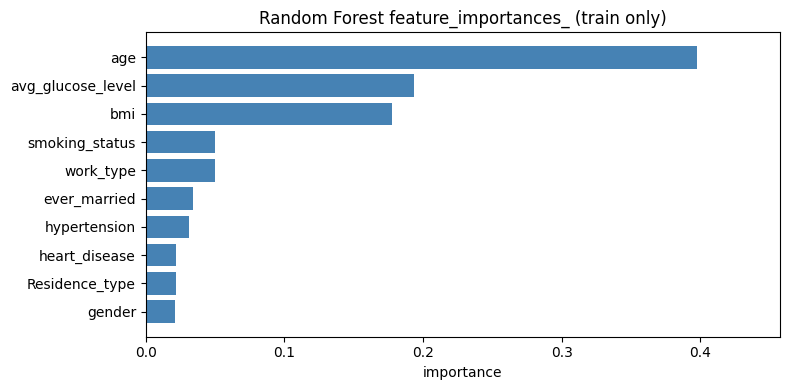

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(out_df["feature"][::-1], out_df["importance"][::-1], color="steelblue")
ax.set_xlabel("importance")
ax.set_title("Random Forest feature_importances_ (train only)")
ax.set_xlim(0, max(out_df["importance"]) * 1.15)
plt.tight_layout()


## Baseline Models


In [7]:
def build_baseline_models():
    return {
        "lr": LogisticRegression(random_state=42, C=0.1, class_weight="balanced", solver="newton-cg"),
        "svm": SVC(C=10.0, class_weight="balanced", gamma=0.01, kernel="rbf"),
        "rf": RandomForestClassifier(
            bootstrap=True,
            class_weight="balanced_subsample",
            max_depth=15,
            max_features=None,
            max_leaf_nodes=15,
            n_estimators=20,
            random_state=42,
        ),
        "xgb": XGBClassifier(
            eta=1,
            gamma=1,
            reg_lambda=0.5,
            max_depth=15,
            objective="binary:logistic",
            subsample=1,
            scale_pos_weight=19,
            eval_metric="logloss",
        ),
    }


def metric_row(model_name, subset_name, Xtr, Xte):
    model = clone(build_baseline_models()[model_name])
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    return {
        "model": model_name,
        "subset": subset_name,
        "n_features": Xtr.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, pos_label=1),
        "precision": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_test, pred, pos_label=1, zero_division=0),
    }


## Evaluate Full vs Top-k Feature Subsets Across All Baselines


In [8]:
subset_data = {"full": (X_train, X_test)}
for k in TOP_K_CANDIDATES:
    subset_data[f"top-{k}"] = (X_train[:, order[:k]], X_test[:, order[:k]])

rows = []
for model_name in build_baseline_models():
    for subset_name, (Xtr, Xte) in subset_data.items():
        rows.append(metric_row(model_name, subset_name, Xtr, Xte))

eval_df = pd.DataFrame(rows).sort_values(["model", "n_features"]).reset_index(drop=True)
eval_df.style.format({
    "accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
}).hide(axis="index")


model,subset,n_features,accuracy,f1,precision,recall
lr,top-3,3,0.7407,0.2319,0.1356,0.8000
lr,top-5,5,0.7407,0.2319,0.1356,0.8000
lr,top-8,8,0.7495,0.2381,0.1399,0.8000
lr,full,10,0.7466,0.2360,0.1384,0.8000
lr,top-10,10,0.7466,0.2360,0.1384,0.8000
rf,top-3,3,0.7769,0.2597,0.1550,0.8000
rf,top-5,5,0.7808,0.2632,0.1575,0.8000
rf,top-8,8,0.7789,0.2614,0.1562,0.8000
rf,full,10,0.7789,0.2614,0.1562,0.8000
rf,top-10,10,0.7789,0.2614,0.1562,0.8000


## Pivot View For Easier Comparison


In [9]:
eval_df.pivot(index="model", columns="subset", values=["accuracy", "f1", "precision", "recall"]).round(4)


accuracy                                      f1                  \
subset     full  top-10   top-3   top-5   top-8    full  top-10   top-3   
model                                                                     
lr       0.7466  0.7466  0.7407  0.7407  0.7495  0.2360  0.2360  0.2319   
rf       0.7789  0.7789  0.7769  0.7808  0.7789  0.2614  0.2614  0.2597   
svm      0.7339  0.7339  0.7025  0.7055  0.7133  0.2229  0.2229  0.2083   
xgb      0.9061  0.9149  0.9139  0.9247  0.9159  0.1429  0.1869  0.1538   

                       precision                                 recall  \
subset   top-5   top-8      full  top-10   top-3   top-5   top-8   full   
model                                                                     
lr      0.2319  0.2381    0.1384  0.1384  0.1356  0.1356  0.1399   0.80   
rf      0.2632  0.2614    0.1562  0.1562  0.1550  0.1575  0.1562   0.80   
svm     0.2100  0.2187    0.1300  0.1300  0.1198  0.1208  0.1262   0.78   
xgb     0.2062  0.2321    0.1290  0.1754  0.1481  0.2128  0.2097   0.16   

                                 
subset top-10 top-3 top-5 top-8  
model                            
lr       0.80  0.80   0.8  0.80  
rf       0.80  0.80   0.8  0.80  
svm      0.78  0.80   0.8  0.82  
xgb      0.20  0.16   0.2  0.26

## Optional Export


In [10]:
expanded_out = REPO_ROOT / "src/feature_selection/importance_rf_expand_results.csv"
eval_df.to_csv(expanded_out, index=False)
expanded_out


PosixPath('/Users/brad/gitClones/Stroke-Prediction-ML/src/feature_selection/importance_rf_expand_results.csv')

## ADDED FOR PRESENTATION: F1 Comparison Chart

This section was added for presentation slides. It keeps the existing notebook results and creates a cleaner grouped bar chart for slide use.


,model,subset,n_features,f1
0,lr,full,10,0.235988
1,lr,top-8,8,0.238095
2,rf,full,10,0.261438
3,rf,top-8,8,0.261438
4,svm,full,10,0.222857
5,svm,top-8,8,0.218667
6,xgb,full,10,0.142857
7,xgb,top-8,8,0.232143


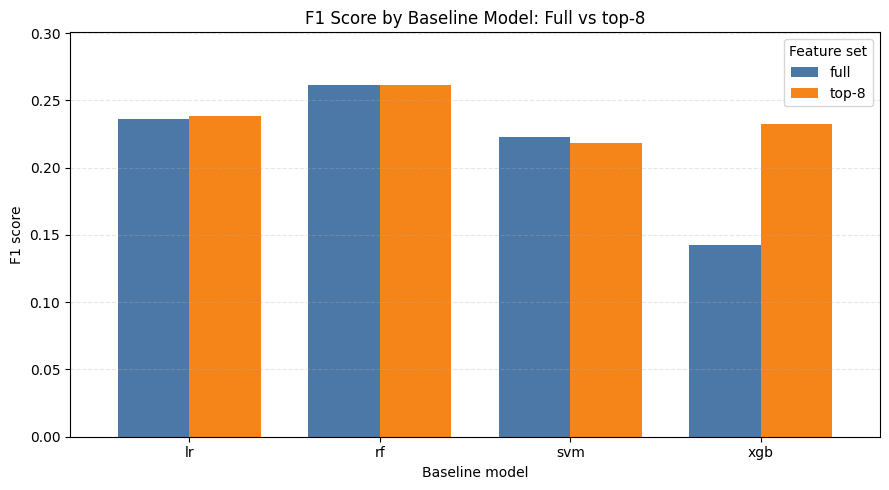

In [11]:
# ADDED FOR PRESENTATION: choose one top-k subset to compare against the full feature set.
# We select the top-k option with the highest average F1 across baseline models
# so the slide can show one clean comparison instead of several crowded plots.
presentation_candidates = eval_df[eval_df["subset"] != "full"].copy()
avg_f1_by_subset = (
    presentation_candidates.groupby("subset", as_index=False)["f1"]
    .mean()
    .sort_values("f1", ascending=False)
)
best_subset_name = avg_f1_by_subset.iloc[0]["subset"]

# ADDED FOR PRESENTATION: keep only the full-feature result and the chosen subset.
presentation_df = eval_df[eval_df["subset"].isin(["full", best_subset_name])].copy()
presentation_df["subset"] = pd.Categorical(
    presentation_df["subset"],
    categories=["full", best_subset_name],
    ordered=True,
)
presentation_df = presentation_df.sort_values(["model", "subset"]).reset_index(drop=True)

# ADDED FOR PRESENTATION: build a grouped bar chart using F1 score,
# which is more informative than accuracy for our imbalanced stroke dataset.
pivot_f1 = presentation_df.pivot(index="model", columns="subset", values="f1")
ax = pivot_f1.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#4C78A8", "#F58518"],
    width=0.75,
)
ax.set_title(f"F1 Score by Baseline Model: Full vs {best_subset_name}")
ax.set_xlabel("Baseline model")
ax.set_ylabel("F1 score")
ax.set_ylim(0, max(0.05, float(pivot_f1.max().max()) * 1.15))
ax.legend(title="Feature set")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()

# ADDED FOR PRESENTATION: also show the exact F1 values under the plot
# in case we want a quick screenshot of the numbers for the slide notes.
presentation_df[["model", "subset", "n_features", "f1"]].sort_values(["model", "subset"])
